# 04 · Visualising MNIST in 2D: t-SNE vs PCA, Kernel PCA, LLE, Isomap and MDS

**Question:** which method gives the most useful 2D picture of MNIST (exercise 10)?

How a map is scored: a map is good if the digits form separate regions. The pipeline measures this with the 5-fold cross-validated accuracy of a 5-nearest-neighbours classifier on the 2D coordinates. This follows the book's answer to exercise 7: judge a reduction by the performance of the algorithm that uses it. The nonlinear methods run after a PCA that keeps 95% of the variance (exercise 8: chaining reductions). t-SNE is also run on the raw pixels as a control.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dimred_mlops.config import load_config
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
CFG = load_config(ROOT / "configs/full_flow_config.yaml")
SEED = CFG["seed"]
# figures are drawn into a temporary folder: reports/figures belongs to the pipeline run
import tempfile
FIG = Path(tempfile.mkdtemp(prefix="nb-figures-"))

In [2]:
from dimred_mlops.data import load_mnist_split
split = load_mnist_split(ROOT / "data")     # first 60,000 = train, last 10,000 = test
X_train, y_train, X_test, y_test = split.X_train, split.y_train, split.X_test, split.y_test
split.sizes

{'n_train': 60000, 'n_test': 10000, 'n_features': 784}

In [3]:
from dimred_mlops.maps import run_part_d
d = run_part_d(split, CFG["part_d"], SEED)
print("kNN on all 784 pixels (no reduction):", round(d.metrics["knn_accuracy_784d"], 3))
d.table.round(3)

kNN on all 784 pixels (no reduction): 0.928


,method,seconds,knn_accuracy_2d,knn_std
0,PCA,0.278,0.414,0.014
1,Kernel PCA,1.307,0.407,0.019
2,LLE,5.295,0.682,0.012
3,Isomap,5.789,0.504,0.016
4,MDS,187.698,0.453,0.008
5,t-SNE,16.505,0.933,0.009
6,t-SNE (raw pixels),15.653,0.929,0.008


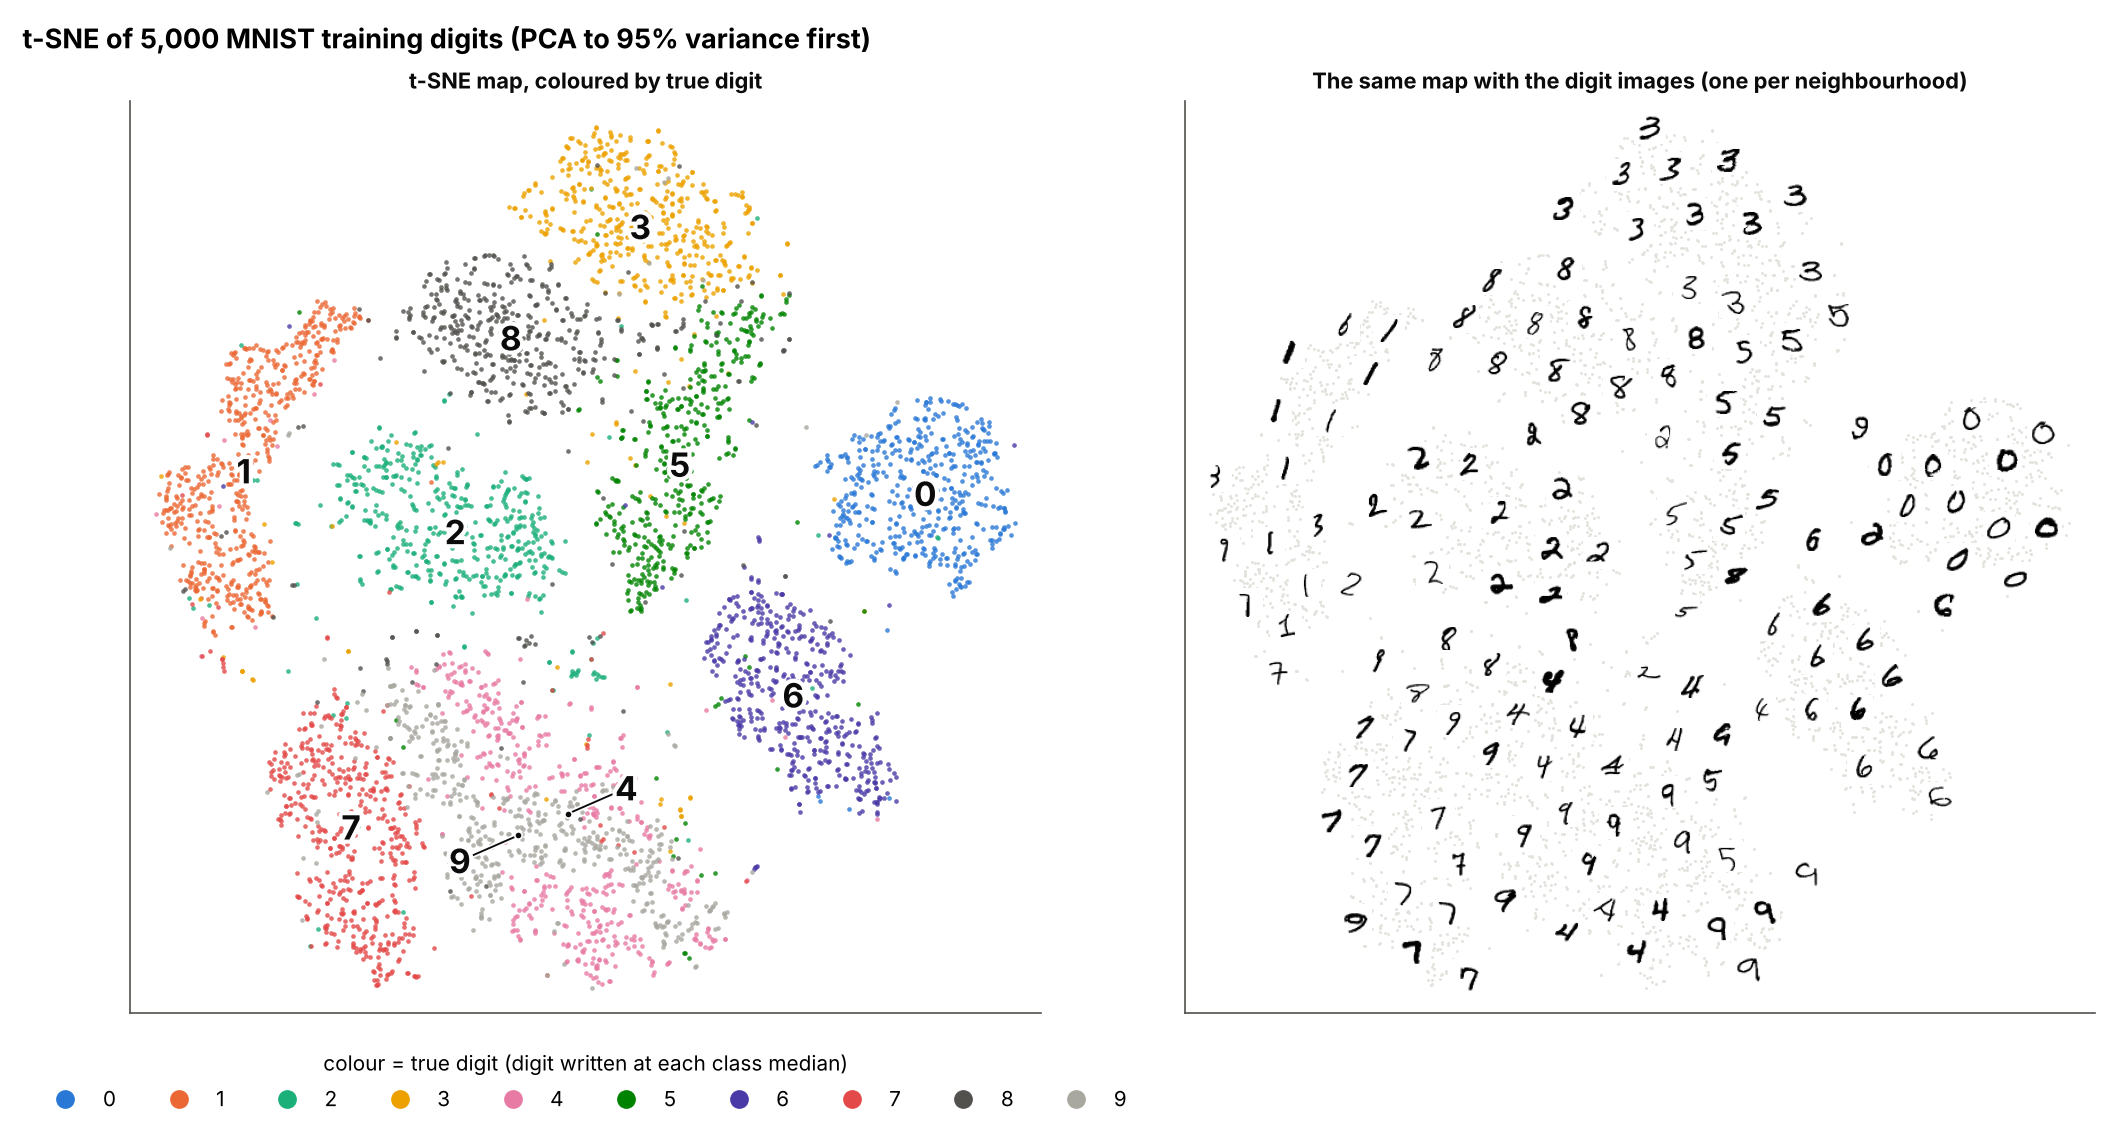

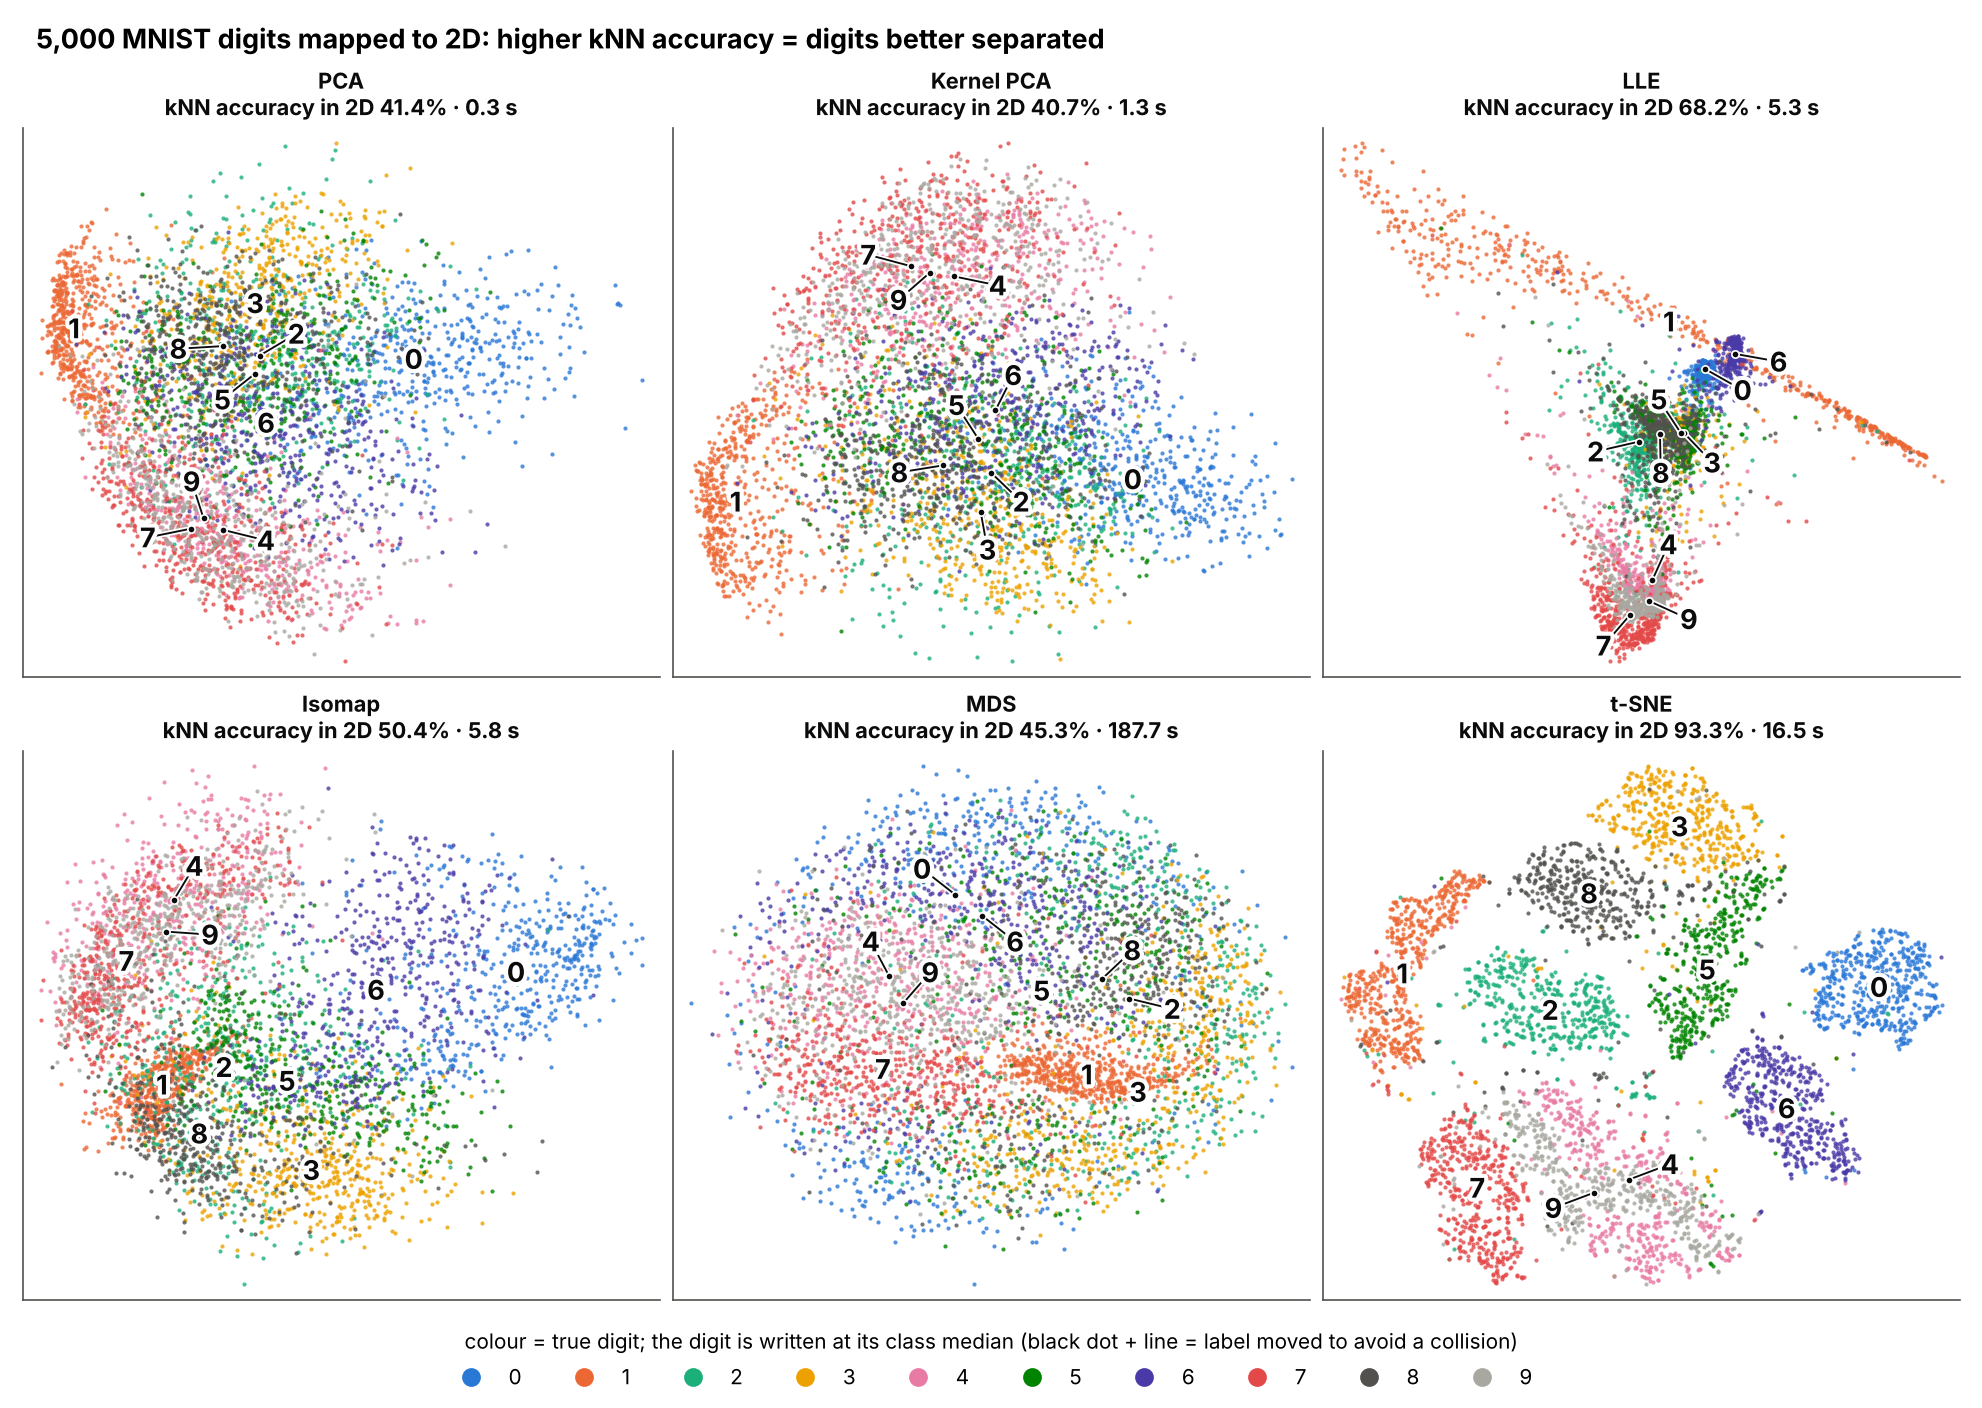

In [4]:
from dimred_mlops import plots
plots.tsne_map(d.embeddings["t-SNE"], d.labels, d.images, FIG / "d_tsne_map.png")
plots.maps_comparison(d.embeddings, d.labels, d.table, FIG / "d_maps_comparison.png")
display(Image(str(FIG / "d_tsne_map.png"), width=950)); display(Image(str(FIG / "d_maps_comparison.png"), width=950))

## Which maps can place a new digit?
PCA, Kernel PCA and LLE have a `transform()` method. t-SNE and MDS do not: they only embed the points they were fitted on. Isomap has one, but it needs the stored geodesic distance matrix (n² values). The deployed *embedding atlas* therefore places new inputs on the PCA, Kernel PCA and LLE maps.

In [5]:
pos = d.atlas.project(X_test[:3])
{k: np.round(v, 3).tolist() for k, v in pos.items()}, y_test[:3]

({'PCA': [[0.229, 0.216], [0.328, 0.811], [0.037, 0.617]],
  'Kernel PCA': [[0.34, 0.838], [0.449, 0.164], [0.032, 0.316]],
  'LLE': [[0.468, 0.057], [0.559, 0.523], [0.428, 0.715]]},
 array([7, 2, 1]))

## Takeaways
* t-SNE separates the digits far better than every other method: about 93% kNN accuracy in 2D, against about 41% for PCA. A kNN on all 784 pixels scores about 93% on the same 5,000 digits, so two t-SNE coordinates separate the digits as well as the full pixel vectors do.
* The score is computed on maps fitted to all 5,000 points (t-SNE cannot map new points), so the points each fold tests on have already shaped the map. This flatters t-SNE a little: the score describes the map, not a held-out classifier.
* Running PCA to 95% first makes no difference to t-SNE's quality.
* MDS is by far the slowest and barely beats PCA.